# Segmenter comparison -- Patch grid vs SLIC superpixels

Same CLIP ViT-B/32 model, same image and text, **same masker** (`crossmodal_mean`).
Only the **segmenter** changes:

1. **Patch** (default) -- the rigid ViT patch grid (7x7 = 49 square players).
2. **SLIC** -- content-adaptive superpixels that follow object boundaries.

This isolates *what the choice of segmenter changes* in the explanation.

> **CPU-friendly.** Runs on CPU with a small FIxLIP budget (~1 min). SLIC does
> **not** require a CNN backbone -- it is applied to the same ViT model here,
> so no OpenAI CLIP ResNet / adapter is needed.

In [1]:
from pathlib import Path
import sys, time

import numpy as np
import torch
torch.set_float32_matmul_precision("high")

from PIL import Image
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
import shapiq

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.fixlip import FIxLIP
from src import utils
from src.plot import plot_image_and_text_together, plot_slicimage_and_text_together
from shapiq.imputer.vision import (
    VisionImputerFactory,
    VisionLanguageGame,
    SegmenterConfig,
    SlicParams,
)

# CPU-only example (keeps it runnable on doc-building runners).
DEVICE = torch.device("cpu")
print("device:", DEVICE)

device: cpu


## Load model and data

In [2]:
MODEL_ID = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(MODEL_ID).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(MODEL_ID)

input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png").convert("RGB")

print(f"Model: {MODEL_ID}")
print(f"Image size: {input_image.size}")
print(f"Text: '{input_text}'")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Model: openai/clip-vit-base-patch32
Image size: (511, 511)
Text: 'black dog next to a yellow hydrant'


## Build two imputers -- only the segmenter differs

Both imputers use the default `crossmodal_mean` masker. The single variable is
the segmenter: rigid **patch** grid vs content-adaptive **SLIC** superpixels.

In [3]:
factory = VisionImputerFactory()

# (1) Patch segmenter -- the default ViT grid.
imputer_patch = factory.build(model, processor, input_image, input_text)

# (2) SLIC segmenter -- content-adaptive superpixels on the SAME ViT model.
#     The masker is left at the default (crossmodal_mean) for both, so the
#     only variable across the two runs is the segmenter.
seg_slic = SegmenterConfig(strategy="slic", slic=SlicParams(n_segments=30))
imputer_slic = factory.build(
    model, processor, input_image, input_text,
    segmenter_config=seg_slic,
)

print(f"patch: segmenter={imputer_patch.segmenter.config.strategy}, "
      f"n_img={imputer_patch.n_players_image}")
print(f"slic : segmenter={imputer_slic.segmenter.config.strategy}, "
      f"n_img={imputer_slic.n_players_image}")

patch: segmenter=patch, n_img=49
slic : segmenter=slic, n_img=16


## Create game wrappers

In [4]:
BATCH_SIZE = 32

game_patch = VisionLanguageGame(imputer_patch, batch_size=BATCH_SIZE)
game_slic  = VisionLanguageGame(imputer_slic,  batch_size=BATCH_SIZE)

for name, g in [("patch", game_patch), ("slic", game_slic)]:
    print(f"{name}: n_img={g.n_players_image}, n_txt={g.n_players_text}, "
          f"empty={g.empty_value:.2f}, full={g.full_value:.2f}")

patch: n_img=49, n_txt=8, empty=22.87, full=33.94
slic: n_img=16, n_txt=8, empty=22.87, full=33.94


## Compute explanations (2nd-order, small budget)

In [5]:
# Meeting spec: 2nd-order interactions, ~5k budget. On CPU we use a smaller
# budget to keep runtime near ~1 min; raise BUDGET for sharper maps.
BUDGET = 2048

def explain(game):
    fixlip = FIxLIP(
        n_players_image=game.n_players_image,
        n_players_text=game.n_players_text,
        max_order=2,
        p=0.5,
        mode="banzhaf",
        random_state=0,
    )
    utils.set_seed(0)
    t0 = time.perf_counter()
    iv = fixlip.approximate_crossmodal(game, budget=BUDGET)
    return iv, time.perf_counter() - t0

iv_patch, t_patch = explain(game_patch)
print(f"patch done in {t_patch:.1f}s")
iv_slic, t_slic = explain(game_slic)
print(f"slic  done in {t_slic:.1f}s")

patch done in 23.8s
slic  done in 3.9s


## Denormalise image and pad tokens for plotting

In [6]:
def denorm(game):
    img = utils.denormalize(
        game.inputs["pixel_values"].squeeze(0),
        game.processor.image_processor.image_mean,
        game.processor.image_processor.image_std,
    ).permute(1, 2, 0).numpy()
    return np.clip(img, 0.0, 1.0)

text_tokens = input_text.split()
if len(text_tokens) < game_patch.n_players_text:
    text_tokens = text_tokens + [""] * (game_patch.n_players_text - len(text_tokens))

## Visualize -- Patch grid (rigid 7x7)

c:\Image-Explanations-with-shapiq\src\utils.py:175: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return shapiq.InteractionValues(
c:\Image-Explanations-with-shapiq\src\utils.py:378: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(
c:\Users\Lishenna\anaconda3\envs\shapiq_demo\Lib\site-packages\shapiq\interaction_values.py:707: UserWarning: Index `FWBII` is not a valid interaction index. Valid indices are: SII, BII, CHII, Co-Moebius, SGV, BGV, CHGV, IGV, EGV, k-SII, STII, FSII, kADD-SHAP, FBII, SV, BV, JointSV, Moebius, ELC.
  return InteractionValues(


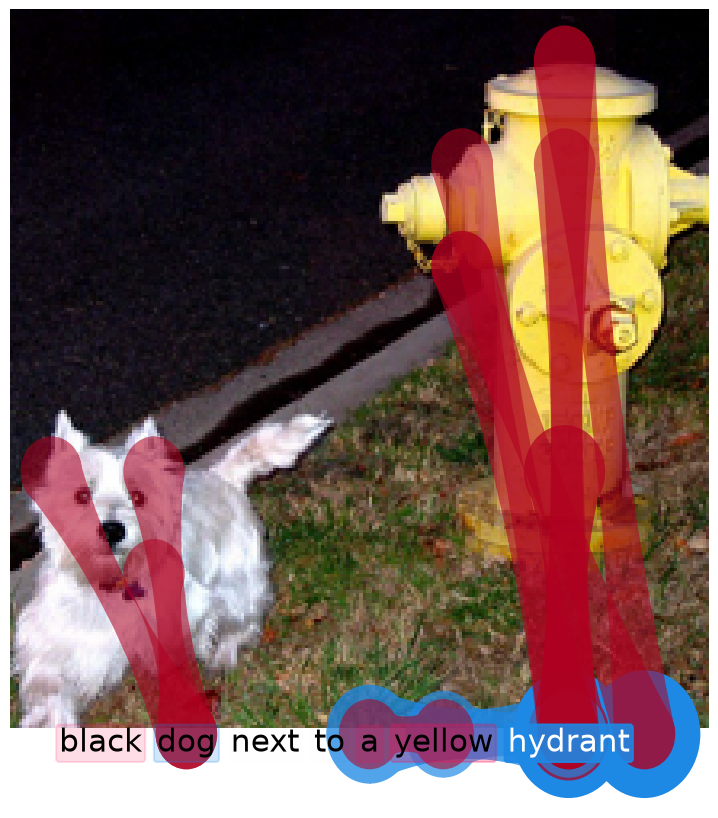

In [7]:
plot_image_and_text_together(
    img=denorm(game_patch),
    text=text_tokens,
    image_players=list(range(game_patch.n_players_image)),
    iv=iv_patch,
    plot_heatmap=True,
    plot_interactions=True,
    top_k=14,
    figsize=(7, 8),
    fontsize=22,
)

## Visualize -- SLIC superpixels (content-adaptive)

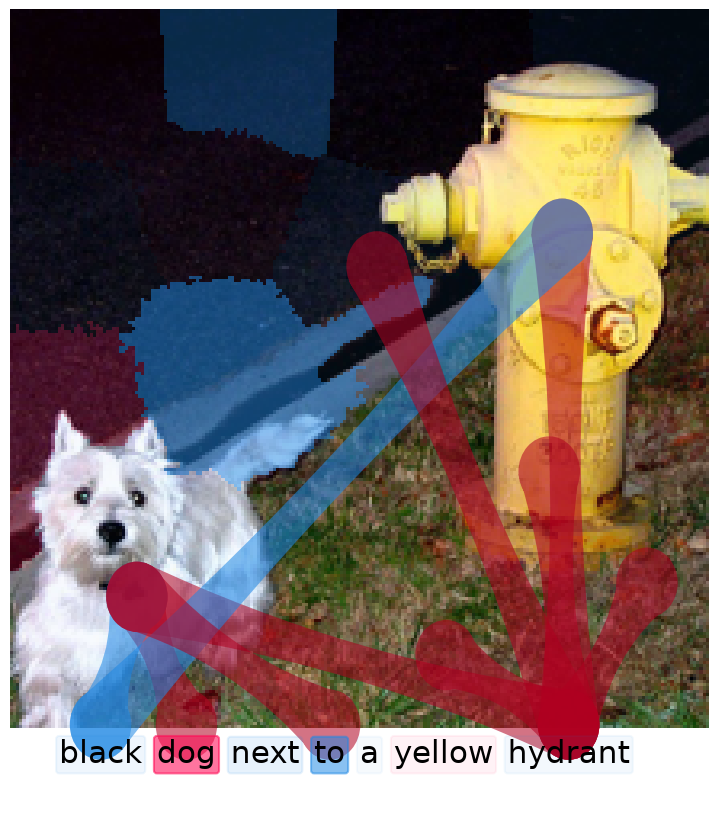

In [8]:
plot_slicimage_and_text_together(
    img=denorm(game_slic),
    text=text_tokens,
    image_players=list(range(game_slic.n_players_image)),
    iv=iv_slic,
    segmenter=imputer_slic.segmenter,
    plot_heatmap=True,
    plot_interactions=True,
    top_k=14,
    figsize=(7, 8),
    fontsize=22,
)

## Takeaway

- **Patch** splits the image into a fixed 7x7 grid regardless of content: some
  players straddle object boundaries, others cover pure background.
- **SLIC** produces fewer, content-adaptive regions that follow the dog and the
  hydrant, so each player is more semantically coherent.
- The masker is identical in both runs, so any difference in the explanation
  comes purely from *how the image is partitioned into players*.